<a href="https://colab.research.google.com/github/evelyn450511/ModelosEstocasticos-EDTS-/blob/main/Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tuturial de SymPy y Networkx**

*Evelyn Daniela Tapia Serrano*

# **1.Configuración Inicial**

Primero, importamos las librerías y configuramos la impresión matemática para que las matrices se vean  de mejor manera.

In [1]:
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt

# Configura SymPy para imprimir en formato matemático (LaTeX)
sp.init_printing()

# Definimos símbolos si es necesario
t = sp.symbols('t')


#**2. Operaciones con Matrices y Vectores**
En SymPy, las matrices se definen con $sp.Matrix()$ , los vectores son simplemente matrices de una sola columna.


In [2]:
# Definición de una matriz A y un vector v
A = sp.Matrix([[3, 5], [4, 4]])
v = sp.Matrix([5, 9])

# Multiplicación de Matriz por Vector
resultado_mv = A * v

# Potencia de una matriz (A al cuadrado)
A_cuadrado = A**2

print("Matriz A:")
display(A)
print("Vector v:")
display(v)
print("Resultado A * v:")
display(resultado_mv)
print("A elevada al cuadrado:")
display(A_cuadrado)


Matriz A:


⎡3  5⎤
⎢    ⎥
⎣4  4⎦

Vector v:


⎡5⎤
⎢ ⎥
⎣9⎦

Resultado A * v:


⎡60⎤
⎢  ⎥
⎣56⎦

A elevada al cuadrado:


⎡29  35⎤
⎢      ⎥
⎣28  36⎦

Para resolver un sistema del tipo $Ax = b$, podemos usar el método $LUsolve$ o simplemente multiplicar por la $inversa$.

In [3]:
# Sistema: 3x + 2y = 5
#          3x + 4y = 10
A_sys = sp.Matrix([[3, 2], [3, 4]])
b = sp.Matrix([5, 10])

# Solución x = A^-1 * b
solucion = A_sys.solve(b)

print("La solución al sistema es:")
display(solucion)


La solución al sistema es:


⎡ 0 ⎤
⎢   ⎥
⎣5/2⎦

**4. Valores y Vectores Propios (Eigenvalues/Eigenvectors)**

SymPy devuelve los valores propios con su respectiva multiplicidad algebraica.


In [4]:
M = sp.Matrix([[8, -2], [4, 10]])

# Valores propios (devuelve un diccionario: {valor: multiplicidad})
eigenvals = M.eigenvals()

# Vectores propios (devuelve una lista de tuplas: (valor, mult, [vector]))
eigenvects = M.eigenvects()

print("Valores propios de M:")
display(eigenvals)
print("Vectores propios de M:")
display(eigenvects)


Valores propios de M:


{9 - √7⋅ⅈ: 1, 9 + √7⋅ⅈ: 1}

Vectores propios de M:


⎡⎛             ⎡⎡  1   √7⋅ⅈ⎤⎤⎞  ⎛             ⎡⎡  1   √7⋅ⅈ⎤⎤⎞⎤
⎢⎜             ⎢⎢- ─ - ────⎥⎥⎟  ⎜             ⎢⎢- ─ + ────⎥⎥⎟⎥
⎢⎜9 - √7⋅ⅈ, 1, ⎢⎢  4    4  ⎥⎥⎟, ⎜9 + √7⋅ⅈ, 1, ⎢⎢  4    4  ⎥⎥⎟⎥
⎢⎜             ⎢⎢          ⎥⎥⎟  ⎜             ⎢⎢          ⎥⎥⎟⎥
⎣⎝             ⎣⎣    1     ⎦⎦⎠  ⎝             ⎣⎣    1     ⎦⎦⎠⎦

#**5. Diagramas de Transición con NetworkX**

Para representar, por ejemplo, una $Cadena$ $de$ $Markov$ o un $diagrama$ $de$ $estados$, usamos un grafo dirigido (DiGraph).

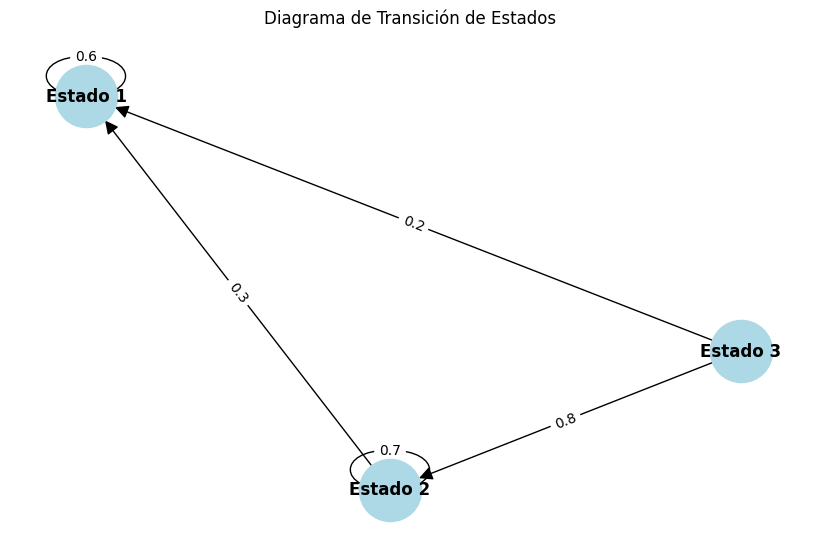

In [8]:
# Crear el objeto del diagrama(grafo)
G = nx.DiGraph()

# Agregar aristas con pesos (probabilidades de transición)
# (Nodo origen, Nodo destino, probabilidad/peso )
transiciones = [
    ("Estado 1", "Estado 1", 0.6),
    ("Estado 2", "Estado 2", 0.4),
    ("Estado 2", "Estado 1", 0.3),
    ("Estado 2", "Estado 2", 0.7),
    ("Estado 3", "Estado 1", 0.2),
    ("Estado 3", "Estado 2", 0.8)
]

G.add_weighted_edges_from(transiciones)

# Dibujar el diagrama
pos = nx.spring_layout(G) # Posicionamiento de los nodos
plt.figure(figsize=(8, 5))

# Dibujar nodos y etiquetas
nx.draw(G, pos, with_labels=True, node_color='lightblue',
        node_size=2000, font_weight='bold', arrowsize=20)

# Dibujar los pesos de las aristas
labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Diagrama de Transición de Estados")
plt.show()


#**6.Funciones importantes con SymPy**

**Matrices Simbólicas**


Una de las mayores ventajas de SymPy es que no se necesitan números. Se puede trabajar con variables para obtener fórmulas generales.

In [9]:
# Definimos variables simbólicas
a, b, c, d = sp.symbols('a b c d')

# Creamos una matriz genérica 2x2
M_simb = sp.Matrix([[a, b], [c, d]])

print("Matriz Simbólica:")
display(M_simb)

# Determinante e Inversa simbólica
print("Determinante de la matriz:")
display(M_simb.det())

print("Inversa de la matriz:")
display(M_simb.inv())


Matriz Simbólica:


⎡a  b⎤
⎢    ⎥
⎣c  d⎦

Determinante de la matriz:


a⋅d - b⋅c

Inversa de la matriz:


⎡    d         -b    ⎤
⎢─────────  ─────────⎥
⎢a⋅d - b⋅c  a⋅d - b⋅c⎥
⎢                    ⎥
⎢   -c          a    ⎥
⎢─────────  ─────────⎥
⎣a⋅d - b⋅c  a⋅d - b⋅c⎦

**2. Polinomio Característico**

El polinomio característico es la base para encontrar los valores propios. Se define como $p(\lambda) = \det(A - \lambda I)$.

In [10]:
lamda = sp.symbols('lambda')
A = sp.Matrix([[1, 2], [3, 4]])

# Obtener el polinomio característico
poly = A.charpoly(lamda)

print(f"Polinomio característico de A:")
display(poly.as_expr())

# Factorización del polinomio
print("Factorizado:")
display(sp.factor(poly.as_expr()))


Polinomio característico de A:


 2          
λ  - 5⋅λ - 2

Factorizado:


 2          
λ  - 5⋅λ - 2

**3. Diagonalización**

Si una matriz $A$ es diagonalizable, podemos escribirla como $A = PDP^{-1}$, donde $D$ es una matriz diagonal de valores propios y $P$ contiene los vectores propios.

In [11]:
B = sp.Matrix([[3, -2,  4], [-2,  6,  2], [4,  2,  3]])

# P es la matriz de paso, D es la matriz diagonal
P, D = B.diagonalize()

print("Matriz de paso (P):")
display(P)
print("Matriz diagonal (D):")
display(D)

# Verificación: P * D * P^-1 debe ser igual a B
print("Verificación (P * D * P^-1):")
display(P * D * P**-1)


Matriz de paso (P):


⎡-2  -1  1⎤
⎢         ⎥
⎢-1  2   0⎥
⎢         ⎥
⎣2   0   1⎦

Matriz diagonal (D):


⎡-2  0  0⎤
⎢        ⎥
⎢0   7  0⎥
⎢        ⎥
⎣0   0  7⎦

Verificación (P * D * P^-1):


⎡3   -2  4⎤
⎢         ⎥
⎢-2  6   2⎥
⎢         ⎥
⎣4   2   3⎦

**4. Integración y Derivación de Matrices**

SymPy permite aplicar cálculo directamente sobre los elementos de una matriz.


In [12]:
# Matriz con funciones de t
M_func = sp.Matrix([[sp.sin(t), sp.cos(t)], [sp.exp(t), t**2]])

print("Matriz original:")
display(M_func)

# Derivada respecto a t
print("Derivada de la matriz:")
display(M_func.diff(t))

# Integral respecto a t
print("Integral de la matriz:")
display(M_func.integrate(t))


Matriz original:


⎡sin(t)  cos(t)⎤
⎢              ⎥
⎢   t       2  ⎥
⎣  ℯ       t   ⎦

Derivada de la matriz:


⎡cos(t)  -sin(t)⎤
⎢               ⎥
⎢   t           ⎥
⎣  ℯ       2⋅t  ⎦

Integral de la matriz:


⎡-cos(t)  sin(t)⎤
⎢               ⎥
⎢            3  ⎥
⎢   t       t   ⎥
⎢  ℯ        ──  ⎥
⎣           3   ⎦

# **7. Funciones de Networkx**

**1. Análisis de Conectividad**

Ya que en los diagramas de transición, es importante saber si el sistema puede quedar "atrapado" en un grupo de estados.

In [13]:
# Verificar si el grafo es fuertemente conexo
# (¿puedes llegar de cualquier nodo a cualquier otro?)
es_conexo = nx.is_strongly_connected(G)

# Encontrar los componentes fuertemente conexos
componentes = list(nx.strongly_connected_components(G))

print(f"¿Es el sistema totalmente recurrente?: {es_conexo}")
print(f"Grupos de estados conectados: {componentes}")


¿Es el sistema totalmente recurrente?: False
Grupos de estados conectados: [{'Estado 1'}, {'Estado 2'}, {'Estado 3'}]


**2. De Grafo a Matriz de SymPy (y viceversa)**

Una de las funciones más útil, pues nos permite dibujar un grafo manualmente y convertirlo en una matriz para operar con SymPy.

In [14]:
# Obtener la matriz de adyacencia (o de transición) desde el grafo
# nodelist asegura que el orden de las filas/columnas sea el que queremos
nodos = sorted(G.nodes())
adj_matrix_np = nx.to_numpy_array(G, nodelist=nodos)

# Convertir a Matriz de SymPy para cálculos exactos
M_sympy = sp.Matrix(adj_matrix_np)

print("Matriz de transición extraída del grafo:")
display(M_sympy)


Matriz de transición extraída del grafo:


⎡0.6  0.0  0.0⎤
⎢             ⎥
⎢0.3  0.7  0.0⎥
⎢             ⎥
⎣0.2  0.8  0.0⎦